In [286]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [287]:
%autoreload
import sys
import copy
import os 

sys.path.append('../../style_generation_pipeline/')
os.environ['TRANSFORMERS_CACHE'] = '/mnt/swordfish-pool2/milad/hf-cache'
os.environ['HF_DATASETS_CACHE'] = '/mnt/swordfish-pool2/milad/hf-cache'
os.environ['LORA_BASEMODEL_CHECKPOINT_PATH'] = "/mnt/swordfish-pool2/milad/hiatus-data/models/original_ta2_performers_data_model_50k_hrs_continued_final_model/"

#os.environ['LORA_BASEMODEL_CHECKPOINT_PATH'] = "/mnt/swordfish-pool2/milad/hiatus-data/models/ta2-system2-en-submitted-8-01-25/rrivera1849/LUAR-MUD/"
#os.environ['LORA_ADAPTER_CHECKPOINT_PATH'] = "/mnt/swordfish-pool2/milad/hiatus-data/models/ta2-system2-en-submitted-8-01-25/lora_checkpoint/"

import generate_explanations
from utils import hiatus_utils, explanation_interfaces

In [288]:
import json
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.preprocessing import minmax_scale
import random
from data import get_aa_data_from_original_format

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [289]:
def generate_hiatus_explanations(data_point, interp_space_path, interp_space_rep_path, style_feat_clm, style_feat_summary_clm, explanation_interf, cluster_lvl=True, random_feature_assignment=False, max_author_docs=3):

    query_authors, candidate_authors, queries_df, candidates_df, ground_truth_assignment = data_point[0], data_point[1], data_point[2], data_point[3], data_point[4] 
    
    output_json = []
    for q_author_id in query_authors:
    
        q_author_documents = queries_df[queries_df.authorID == q_author_id]['fullText'].tolist()[0]
        c_author_documents = candidates_df.fullText.tolist()

        result = generate_explanations.explain_model_prediction_over_author(model_path, interp_space_path, interp_space_rep_path, \
                                                                            q_author_documents, c_author_documents, top_c=top_c, style_feat_clm=style_feat_clm, \
                                                                            style_feat_summary_clm=style_feat_summary_clm, cluster_lvl=cluster_lvl)

        latent_rank = result[0]
        interp_rank = result[1]

        rep_clusters_ids = []
        if cluster_lvl == True:
            style_reps = result[2]
            style_reps_summ = result[3]
            author_sim_to_styles = result[4]
            query_author_rep_doc_id = result[5]
            candidate_authors_rep_doc_ids = result[6]
            author_latents = result[7]
            author_interps = result[8]
            rep_clusters_ids = result[9]
        else:
            query_author_style_feats = result[2]
            candidate_authors_style_feats = result[3]
            selected_feats = result[4]
            query_author_rep_doc_id = result[5]
            candidate_authors_rep_doc_ids = result[6]
            author_latents = result[7]
            author_interps = result[8]

        # print(q_author_id)
        # print(latent_rank)
        # print(interp_rank)
        instance_json = {
            "Q_fullText": "\n\n".join(["Document {}: \n{}".format(i+1,d) for i, d in enumerate(q_author_documents[:max_author_docs])]),
            #"Q_fullText": q_author_documents[query_author_rep_doc_id],
            "Q_authorID": q_author_id,
            "latent_rank" : latent_rank.tolist(),
            "system_rank" : [{"id": x+1, "title": 'Author {}'.format(x+1), "body": ""} for i, x in enumerate(latent_rank.tolist())],
            "rank_1": "1. Author {}".format(latent_rank[0]+1),
            "rank_2": "2. Author {}".format(latent_rank[1]+1),
            "rank_3": "3. Author {}".format(latent_rank[2]+1),
            "interp_rank" : interp_rank.tolist(),
            "author_latents": [x.tolist() for x in author_latents],
            "author_interps": [x.tolist() for x in author_interps],
            "rep_clusters": rep_clusters_ids
        }

        #print(instance_json['system_rank'])
        #Find candidate authors order
        candidate_author_order = []
        for order, c_author_id in enumerate(candidate_authors):
            instance_json['a{}_fullText'.format(order)] = "\n\n".join(["Document {}: \n{}".format(i+1,d) for i, d in enumerate(c_author_documents[order][:max_author_docs])])
            #instance_json['a{}_fullText'.format(order)] = c_author_documents[order][candidate_authors_rep_doc_ids[order]]
            instance_json['a{}_authorID'.format(order)] = c_author_id
            order+=1
            candidate_author_order.append(candidate_authors.index(c_author_id))

        if cluster_lvl:
            instance_json["author_sim_to_clusters"] = author_sim_to_styles
            instance_json['explanation'] = hiatus_utils.build_explanation_interface1(explanation_interf, author_sim_to_styles, style_reps_summ, candidate_authors, random_feature_assignment=random_feature_assignment)
        else:
            instance_json['explanation'] = hiatus_utils.build_explanation_interface2(explanation_interf, query_author_style_feats, candidate_authors_style_feats, selected_feats, random_feature_assignment=random_feature_assignment)

        #Find the ground-truth labels (who wrote the query document)
        query_author_idx = query_authors.index(q_author_id)
        candidate_atuthor_labels = [ground_truth_assignment[query_author_idx][a_idx] for a_idx in candidate_author_order]
        gt_idx = candidate_atuthor_labels.index(1)
        instance_json["gt_idx"] = gt_idx
        
        output_json.append(instance_json)

    return output_json[0] # it is always one query author per instance

In [290]:
def run_explanation_experiment(input_path, model_path, interp_space_path, interp_space_rep_path, data_generator, output_path, top_c=3, top_k=10):
    output = []
    idx=0

    latent_pred_accuracy = []
    interp_pred_accuracy = []
    for data_point in data_generator:

        # Generate explanations on feature-level
        instance_exp = generate_hiatus_explanations(data_point, interp_space_path, interp_space_rep_path, 'llm_tfidf_weights', 'llm_tfidf_weights', explanation_interfaces.exp_interface_2, cluster_lvl=False)
        instance_exp['source'] = 'feature_lvl_explanation_tfidf'

        latent_pred_accuracy.append(1 if instance_exp['gt_idx'] == instance_exp['latent_rank'][0] else 0)
        interp_pred_accuracy.append(1 if instance_exp['gt_idx'] == instance_exp['latent_rank'][0] and instance_exp['latent_rank'][0] == instance_exp['interp_rank'][0] else 0)
        
        # Generate random equivelant explanations on feature-level
        # instance_exp_random = generate_hiatus_explanations(data_point, interp_space_path, interp_space_rep_path, 'llm_tfidf_weights', 'llm_tfidf_weights', explanation_interfaces.exp_interface_2, cluster_lvl=False, random_feature_assignment=True)
        # instance_exp_random['source'] = 'feature_lvl_explanation_tfidf_random'
        
        # Create an instance with no explanation
        # instance_wo_exp = {x[0]: x[1] for x in instance_exp.items()}
        # instance_wo_exp['explanation'] = '<p>No Explanation</p>'
        # instance_wo_exp['source'] = 'no_explanation'
        
        #output.append(instance_wo_exp)
        #output.append(instance_exp)
        #output.append(instance_exp_random)
        
        # generate explanations on cluster level
        for feat_clm in ['llm_tfidf_rep']:#['llm_tfidf_rep', 'g2v_tfidf_rep']:
            instance_exp = generate_hiatus_explanations(data_point, interp_space_path, interp_space_rep_path, feat_clm, feat_clm, explanation_interfaces.exp_interface_1_1)
            instance_exp['source'] = feat_clm
            output.append(instance_exp)
            
            instance_exp_random = generate_hiatus_explanations(data_point, interp_space_path, interp_space_rep_path, feat_clm, feat_clm, explanation_interfaces.exp_interface_1_1, random_feature_assignment=True)
            instance_exp_random['source'] = feat_clm + '_random'
            output.append(instance_exp_random)
        
        #open(data_point + '/explanation.html', 'w').write(instance_exp['explanation'])
        idx+=1

    print('Latent Accuracy ', sum(latent_pred_accuracy)/len(latent_pred_accuracy))
    print('Interp Accuracy ', sum(interp_pred_accuracy)/len(interp_pred_accuracy))
    json.dump(output, open(output_path, 'w'))
    return output

## Experiment to generate explanation on IARPA's pilot data

In [206]:
input_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability-pilot-samples/'
model_path = 'luar-mud'
#model_path = 'datadreamer-lora'
top_c=3

interp_space_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/lora_ta2_interp_space_clusters/interpretable_space.pkl'
interp_space_rep_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/lora_ta2_interp_space_clusters/interpretable_space_representations.json'

run_explanation_experiment(input_path, model_path, interp_space_path, interp_space_rep_path, hiatus_utils.get_iarapa_pilot_data(input_path),
                           '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/iarapa_pilot_explanations.json', top_c=3, top_k=10)

Latent Accuracy  0.25
Interp Accuracy  0.25


TypeError: Object of type float32 is not JSON serializable

## Experiment on Generating explanations on samples from HRS

In [291]:
os.environ['LORA_BASEMODEL_CHECKPOINT_PATH'] ="/mnt/swordfish-pool2/milad/hiatus-data/models/ta2-system2-en-submitted-8-01-25/rrivera1849/LUAR-MUD/" 
os.environ['LORA_ADAPTER_CHECKPOINT_PATH']   ="/mnt/swordfish-pool2/milad/hiatus-data/models/ta2-system2-en-submitted-8-01-25/lora_checkpoint/"

In [292]:
#model_path = 'aa_model-luar'
model_path = 'datadreamer-lora'
#model_path = 'luar-mud'
input_path = '/mnt/swordfish-pool2/milad/hiatus-data/phase_2/internal_cross_fold_cross_genre/fold_1/test/TA2/hrs2_09-24-24_english_crossGenre-combined/'
top_c=3

# interp_space_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/system2_interp_space_clusters_09/interpretable_space.pkl'
# interp_space_rep_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/system2_interp_space_clusters_09/interpretable_space_representations.json'

interp_space_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/luar_clusters_09/interpretable_space.pkl'
interp_space_rep_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/luar_clusters_09/interpretable_space_representations.json'

output = run_explanation_experiment(input_path, model_path, interp_space_path, interp_space_rep_path, hiatus_utils.get_hrs_data(input_path, num_instances=100, random_seed=737),
                           '/mnt/swordfish-pool2/milad/hiatus-data/explainability_all_data/hrs_explanations.json', top_c=3, top_k=10)

Latent Accuracy  0.8
Interp Accuracy  0.6923076923076923


In [299]:
import pickle as pkl
interp_space = pkl.load(open(interp_space_path, 'rb'))

In [306]:
interp_space_rep = pd.read_json(interp_space_rep_path)

In [308]:
interp_space_rep.head()

cluster_label  \
0              0   
1              1   
2              2   
3              3   
4              4   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             llm_tfidf_rep  \
0                                                                       [Dependency Label:Nominal modifier, Morphology Tag:Foreign word, Dependency Label:Object of preposition, the author assumes the reader has a solid grasp of the subject, Morphology Tag:Bracket punctuation type, Part-of-Speech Bigram:Symbol followed by Punctuation, Part-of-Speech Unigram:Adposition (preposition or postposition), Dependency Label:Prepositional modifier, Morphology Tag:Final punctuation, punctuation:_]   
1         [Morphology Tag:Second person, the author uses extra details to provide more information, Morphology Tag:Relative pronoun type, the content provides a concise overview of the subject, the text maintains a consistent tone, the author uses precise language to improve the writing, Part-of-Speech Bigram:Noun followed by Punctuation, Part-of-Speech Bigram:Auxiliary verb followed by Punctuation, punctuation:’, Part-of-Speech Bigram:Punctuation followed by Subordinating conjunction]   
2                                                    [Part-of-Speech Bigram:Numeral followed by Interjection, Part-of-Speech Bigram:Noun followed by Numeral, Part-of-Speech Unigram:Noun, Dependency Label:Numeric modifier, Morphology Tag:Article pronoun type, Part-of-Speech Bigram:Verb followed by Numeral, Part-of-Speech Bigram:Numeral followed by Noun, Part-of-Speech Bigram:Proper noun followed by Determiner, Part-of-Speech Bigram:Noun followed by Noun, Morphology Tag:Definite article]   
3                        [the author uses a formal tone to emphasize effective communication, Dependency Label:Determiner, Morphology Tag:Article pronoun type, Part-of-Speech Unigram:Determiner, Part-of-Speech Bigram:Numeral followed by Symbol, Part-of-Speech Bigram:Adposition followed by Determiner, Morphology Tag:Definite article, Part-of-Speech Bigram:Determiner followed by Numeral, Part-of-Speech Bigram:Determiner followed by Noun, Part-of-Speech Bigram:Verb followed by Determiner]   
4  [Part-of-Speech Bigram:Adjective followed by Adverb, Part-of-Speech Bigram:Coordinating conjunction followed by Noun, Part-of-Speech Bigram:Subordinating conjunction followed by Coordinating conjunction, punctuation:', Dependency Label:Complement of preposition, Morphology Tag:Reflexive, Morphology Tag:Relative pronoun type, Part-of-Speech Bigram:Adverb followed by Noun, Part-of-Speech Bigram:Particle followed by Determiner, the author uses extra details to provide more information]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [309]:
interp_space[0][1]

{'content is structured': 163.11937225733837,
 'transitional elements': 2240.366171787762,
 'basic level': 75.23021244037099,
 'critical thinking': 2014.3457625188482,
 'simple sentence structures': 2004.6039104904364,
 'tense usage': 445.0903051913532,
 'diverse sentence structures': 2062.6289704517544,
 'good understanding': 1145.7161469513333,
 'technical language': 2790.935219684348,
 'formal tone': 2375.531185669729,
 'complex sentence structures': 2184.304821130491,
 'different sentence styles': 176.5437980715448,
 'consistent verb tense': 1794.6794251566944,
 'uniform structure': 5.599567686881166,
 'figurative language': 1164.1025898503706,
 'professional tone': 1617.5417782408283,
 'effective communication': 1057.8558612906509,
 'transitional phrases': 1257.3542132994976,
 'passive voice': 2473.179372110887,
 'style is formal': 2637.3007507717766,
 'prior knowledge': 1544.7430203791746,
 'technical terms': 3065.7166127446735,
 'complex ideas effectively': 73.67997973104202,
 '

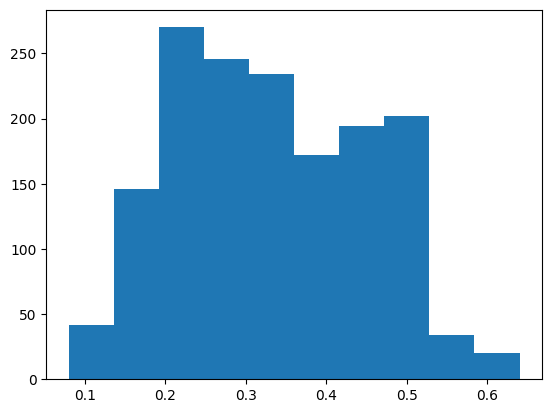

In [293]:
import matplotlib.pyplot as plt
all_values = [round(v,2) for item in output for v in np.array(item['author_sim_to_clusters']).flatten().tolist()]
plt.hist(all_values)
plt.show()

In [294]:
from scipy.stats import zscore

query_interp, candidates_interps = np.array(output[instance_id]['author_interps'][0]), np.array(output[instance_id]['author_interps'][1:])
contributions = np.array([np.abs(query_interp * candidate_interp) for candidate_interp in candidates_interps])
contributions = zscore(contributions, axis=0)
np.argsort(abs(contributions[output[instance_id]['interp_rank'][0]]))[::-1][:3]

array([69, 48,  9])

In [252]:
#np.sort(abs(contributions[output[instance_id]['interp_rank'][0]]))[::-1]

In [295]:
import IPython.display as display
from IPython.display import display, Javascript, HTML

instance_id=5

print('Model Prediction:',  ['Author {}'.format(x+1) for x in output[instance_id]['latent_rank']], 
      'Interp Prediction:', ['Author {}'.format(x+1) for x in output[instance_id]['interp_rank']],
      'Selected Clusters:', output[instance_id]['rep_clusters'],
)
print('=============================')
display(HTML(output[instance_id]['explanation']))

Model Prediction: ['Author 3', 'Author 2', 'Author 1'] Interp Prediction: ['Author 3', 'Author 2', 'Author 1'] Selected Clusters: [27, 1, 4]


Mystery Author,0.17,Author 1,0.23,Author 2,0.17,Author 3,0.23
Mystery Author,0.15,Author 1,0.21,Author 2,0.28,Author 3,0.23
Mystery Author,0.15,Author 1,0.25,Author 2,0.15,Author 3,0.21


In [15]:
import numpy as np

def scale_and_exaggerate(values, power=2):
    values = np.array(values, dtype=float)
    
    # Min-max normalize to [0,1]
    min_val, max_val = values.min(), values.max()
    min_val, max_val = -1, +1
    normalized = (values - min_val) / (max_val - min_val)
    
    # Exaggerate differences using power transformation
    exaggerated = normalized ** power
    
    # Scale to [0,100]
    scaled = exaggerated * 100
    
    return scaled
scale_and_exaggerate([0.54, 0.41, 0.44, 0.41], power=2)

array([59.29  , 49.7025, 51.84  , 49.7025])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_explainable_clusters_from_latent_space(query_latent, candidates_latents, cluster_latents, predicted_author_idx=None, num_clusters=3):
    author_latents = np.vstack([query_latent] + candidates_latents)
    print(author_latents.shape)
    
    pairwise_similarities = cosine_similarity(author_latents, cluster_latents)
    print(pairwise_similarities.shape)
    print(pairwise_similarities)
    contributions = np.array([np.abs(pairwise_similarities[0] * candidate_sim) for candidate_sim in pairwise_similarities[1:]])
    print(contributions)
    contributions = zscore(contributions, axis=0)
    print(contributions)
    #return np.argsort(abs(contributions[predicted_author_idx]))[::-1][:num_clusters]
    return np.argsort(abs(contributions[predicted_author_idx]))[::-1][:num_clusters]


get_explainable_clusters_from_latent_space(np.array([1,1,1]), [np.array([2,1,4]), np.array([1,1,4]), np.array([2,1,5])], [np.array([0,1,1]), np.array([0,1,0]), np.array([1,1,1])], 
                                           predicted_author_idx=0, num_clusters=3)

## Analyze documents style description

In [15]:
interp_space_path = '/mnt/swordfish-pool2/milad/hiatus-data/phase_2/explainability/interpretable_space.pkl'
model_path = 'aa_model-luar'
explanation_interf = explanation_interfaces.exp_interface_1
input_path = '/mnt/swordfish-pool2/milad/hiatus-data/explainability-pilot-samples/'
top_c=3

In [16]:
path_to_input = '/mnt/swordfish-pool2/milad/hiatus-data/explainability-pilot-samples/samples_26_query_79_first/'

In [17]:
candidates_file = list(glob.glob(path_to_input + '/data/*_candidates.jsonl'))[0]
queries_file    = list(glob.glob(path_to_input + '/data/*_queries.jsonl'))[0]
grount_truth_file = list(glob.glob(path_to_input + '/groundtruth/*_groundtruth.npy'))[0]
q_labels_file = glob.glob(path_to_input + '/groundtruth/*_query-labels.txt')[0]
c_labels_file = glob.glob(path_to_input + '/groundtruth/*_candidate-labels.txt')[0]

candidates_df = pd.read_json(candidates_file, lines=True)
queries_df = pd.read_json(queries_file, lines=True)

queries_df['authorID'] = queries_df.authorIDs.apply(lambda x: x[0])
candidates_df['authorID'] = candidates_df.authorSetIDs.apply(lambda x: x[0])

queries_df = queries_df.groupby('authorID').agg({'fullText': lambda x: list(x)}).reset_index()
candidates_df = candidates_df.groupby('authorID').agg({'fullText': lambda x: list(x)}).reset_index()
    
ground_truth_assignment = np.load(open(grount_truth_file, 'rb'))
candidate_authors = [a[2:-3] for a in  open(c_labels_file).read().split('\n')][:-1]
query_authors = [a[2:-3] for a in  open(q_labels_file).read().split('\n')][:-1]

#print(ground_truth_assignment)
#print(candidate_authors)
#print(query_authors)

In [11]:
query_authors

['9265b1f9-31f5-58e5-bfb7-c5979de68d47']

In [12]:
candidate_authors

['07a9a4f0-faed-9b92-fd68-8f47cdc969d5',
 'a83b5d4d-0e79-7ee6-f61b-29b0b059f220',
 'd53e9f35-4c07-3b87-43fc-d52e5f127c6c']

In [13]:
candidate_authors[-1]

'd53e9f35-4c07-3b87-43fc-d52e5f127c6c'

In [14]:
ground_truth_assignment

array([[1, 0, 0]])

In [15]:
matched_candidate_docs = candidates_df[candidates_df.authorID == '07a9a4f0-faed-9b92-fd68-8f47cdc969d5'].fullText.tolist()[0]
other_candidate_docs = candidates_df[candidates_df.authorID != '07a9a4f0-faed-9b92-fd68-8f47cdc969d5'].fullText.tolist()[0] #just pick one other candidate author
query_documents = queries_df.fullText.tolist()[0]

In [16]:
matched_candidate_docs

['The elves had a very distinguished and strict military system, and it included a complex training system that ensured the continued supply of experienced fighters to the army, and this system was based on the soldiers who survived the battles training the new soldiers, as the military system stipulated that the fighters who spent more than 30 years in the war should go to their homeland to train new soldiers in the use of weapons, where the soldier had to prove his competence and strength in order to have the honor of training soldiers.\n\n  But because of the many wars caused by <PERSON> in the first age, and the wars caused by <PERSON> in the second and third ages, where the battles lasted for months, and the siege of castles lasted for years, the elves suffered great losses in their lives, but these losses It was concentrated in the ranks of the swords and spearmen who were always forced to physically interact with the enemy forces, which exposed them to great and permanent danger

In [17]:
other_candidate_docs

["Burning wood has been a local source of warmth for ages, however, while it may provide warmth, it is important to know that burning wood can produce harmful gases such as benzene, and other gases such as carbon monoxide and nitrogen oxides. When organic matter burns, large polycyclic aromatic compounds are released due to combustion. This occurs not only with wood, but also with any other organic matter. Understanding why benzene form in a wood fire, will require us to know what wood is, and how it burns.\n\n  Wood is made up of biomass (matter composed primarily of carbon, hydrogen, and oxygen). This includes things like dry grass, leaves, fibers, animal carcasses, sugar, fat, and coal etc. All of these things contain cellulose or similar molecules, which consists of long chains of aromatic rings.\n\n  When wood is heated up, the molecules composing it start to break apart, in the presence of oxygen, the wood will start to oxidize, this process is what we know as combustion. If ther

In [18]:
query_documents

['The Sahara Desert extends over an area of 9,200,000 square kilometers and is the largest desert in the world. It is one of the driest regions in the world with an average of 25 mm of rain per year. In the past, it was a green area full of rivers, 3 million years ago, until climate change, and the occurrence of several major earthquakes led to the formation of new mountains that blocked the moisture of the sea, and changed the course of the rivers in them, all of this led to the cutting off of water resources and turning it into a dry area with high temperatures, unfit for most types of life.\n\n  Climate change is expected to continue to cause bad consequences for the Sahara desert, as studies indicate that rainfall is expected to decrease by 20 to 30 percent in the next 40 years, and this will lead to more desertification and the destruction of more green spaces on The borders of deserts in general, and will lead to an increase in the borders of the Sahara desert by no less than 7 p

In [19]:
q_documents_reps , q_documents_clusters = generate_explanations.get_documents_style_descriptions(query_documents, model_path, interp_space_path, top_c=3, top_k=5)

TypeError: get_documents_style_descriptions() missing 2 required positional arguments: 'interp_space_rep_path' and 'style_feat_clm'

In [ ]:
c_documents_reps , c_documents_clusters = generate_explanations.get_documents_style_descriptions(matched_candidate_docs, model_path, interp_space_path, top_c=3, top_k=5)

In [ ]:
o_documents_reps , o_documents_clusters = generate_explanations.get_documents_style_descriptions(other_candidate_docs, model_path, interp_space_path, top_c=3, top_k=5)

In [ ]:
q_documents_clusters

In [ ]:
c_documents_clusters

In [ ]:
o_documents_clusters

In [ ]:
q_documents_reps

In [ ]:
c_documents_reps

In [ ]:
o_documents_reps

In [ ]:
interpretable_space = pkl.load(open(interp_space_path, 'rb'))
    
del interpretable_space[-1] #DBSCAN generate a cluster -1 of all outliers. We don't want this cluster
print("# clusters:", len(interpretable_space))
dimension_to_latent = {key: interpretable_space[key][0] for key in interpretable_space}
dimension_to_style  = {key: interpretable_space[key][1] for key in interpretable_space}